In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)


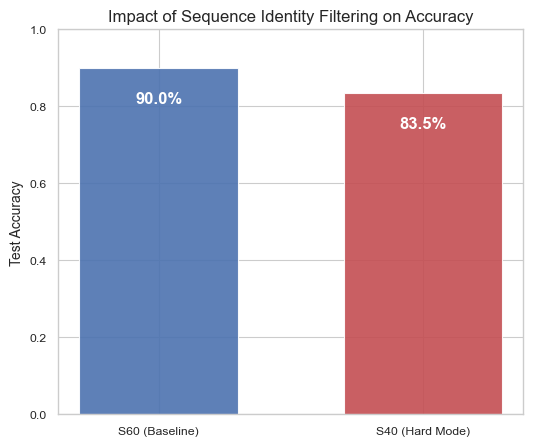

In [26]:
datasets = ['S60 (Baseline)', 'S40 (Hard Mode)']
accuracies = [0.9000, 0.8353]

plt.figure(figsize=(6, 5))
bars = plt.bar(datasets, accuracies, color=['#4c72b0', '#c44e52'], alpha=0.9, width=0.6)

plt.title('Impact of Sequence Identity Filtering on Accuracy', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=10)
plt.ylim(0, 1.0)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height - 0.1,
            f'{height*100:.1f}%',
            ha='center', va='bottom', color='white', fontweight='bold', fontsize=12)

plt.savefig("figure-4c.svg", dpi=300, bbox_inches='tight')


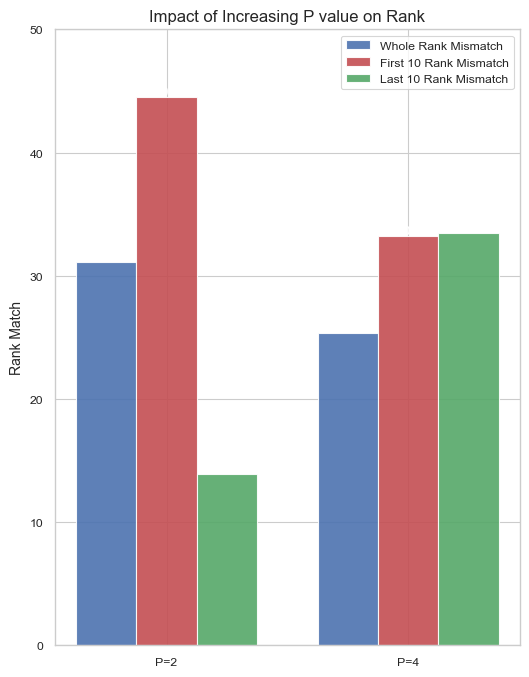

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Data definitions
datasets = ['P=2', 'P=4']

# Replace these arrays with your actual data for each category
# Each list should contain two values: one for S60, one for S40
mean_whole = [np.float64(31.1), np.float64(25.36)]
mean_first_10 = [np.float64(44.5), np.float64(33.2)]
mean_last_10 = [np.float64(13.9), np.float64(33.5)]

# Rank match means (np.float64(44.5), np.float64(31.1), np.float64(13.9))
# Rank match means (np.float64(33.2), np.float64(25.36), np.float64(33.5))


# Set up the bar positions
x = np.arange(len(datasets))
width = 0.25 # Width of the individual bars

plt.figure(figsize=(6, 8))

# Create the grouped bars
# x - width positions the first bar to the left
# x positions the second bar in the center
# x + width positions the third bar to the right
bars1 = plt.bar(x - width, mean_whole, width, label='Whole Rank Mismatch', color='#4c72b0', alpha=0.9)
bars2 = plt.bar(x, mean_first_10, width, label='First 10 Rank Mismatch', color='#c44e52', alpha=0.9)
bars3 = plt.bar(x + width, mean_last_10, width, label='Last 10 Rank Mismatch', color='#55a868', alpha=0.9)

plt.title('Impact of Increasing P value on Rank', fontsize=12)
plt.ylabel('Rank Match', fontsize=10)
plt.ylim(0, 50.0)

# Set the x-axis tick labels to the dataset names
plt.xticks(x, datasets)

# Helper function to add text labels to each set of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        # Adjusted height offset and text size to fit narrower bars
        plt.text(bar.get_x() + bar.get_width() / 2., height - 0.08,
                f'{height*100:.1f}%',
                ha='center', va='bottom', color='white', fontweight='bold', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# Add a legend to identify the 3 categories
plt.legend(loc='upper right')

plt.savefig("figure-4c.svg", dpi=300, bbox_inches='tight')
plt.show()

In [28]:
df = pd.read_pickle("results/run3_final.pkl")
df.head()

,layers,seed,rank_matches
0,1,0,"[19, 47, 1, 10, 7, 42, 2, 8, 8, 7, 9, 1, 19, 4..."
1,1,1,"[15, 48, 1, 10, 8, 42, 0, 7, 8, 7, 7, 0, 19, 4..."
2,1,2,"[19, 48, 0, 10, 8, 42, 0, 8, 8, 6, 9, 0, 19, 4..."
3,1,3,"[14, 47, 1, 8, 9, 42, 1, 10, 8, 7, 7, 1, 12, 4..."
4,1,4,"[18, 48, 0, 9, 9, 42, 1, 7, 8, 6, 9, 0, 19, 41..."


In [29]:
def calculate_average_top100_mismatch(mismatch_array):
    """
    Calculates the average rank displacement for the top 100 classical states.
    A value of 0.0 means perfect ranking parity.
    A value of 5.0 means the top 100 states were off by an average of 5 rank positions.
    """
    # Ensure the array is a numpy array
    mismatch_array = np.array(mismatch_array)

    # Isolate only the top 100 states (or the max length of the array if < 100)
    top_k = min(100, len(mismatch_array))
    top_k_mismatches = mismatch_array[:top_k]

    # Calculate the simple mean of the mismatches
    average_mismatch = np.mean(top_k_mismatches)
    return average_mismatch

def aggregate_mismatches(group):
    # Apply the new mismatch calculation to every seed in the layer group
    seed_mismatches = group['rank_matches'].apply(calculate_average_top100_mismatch).values

    return pd.Series({
        'mean_mismatch': np.mean(seed_mismatches),
        'std_mismatch': np.std(seed_mismatches)
    })



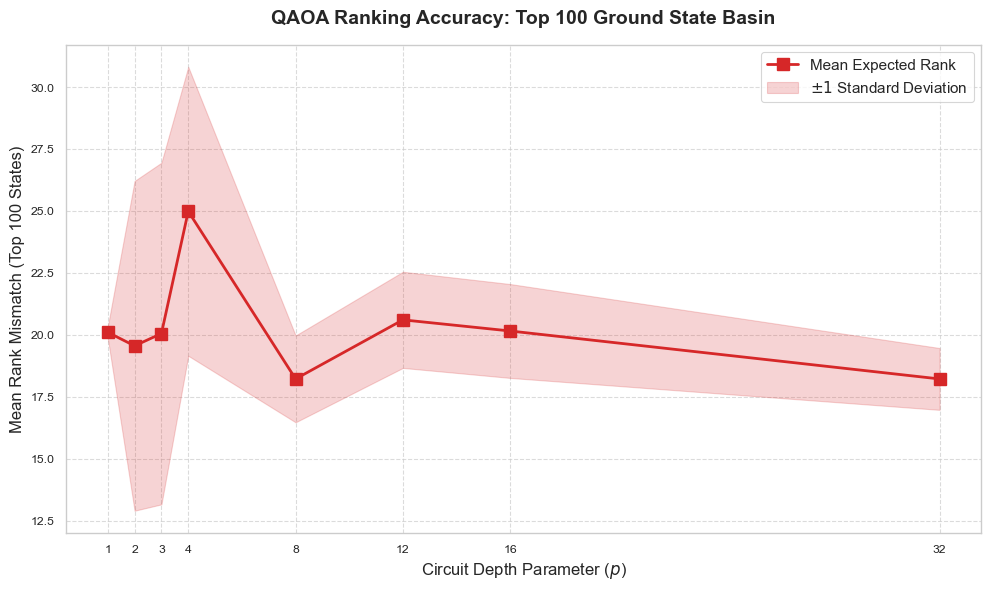

In [30]:
# Apply the aggregation
summary_df = df.groupby('layers').apply(aggregate_mismatches).reset_index()
summary_df

layers = summary_df['layers'].values
mean_ranks = summary_df['mean_mismatch'].values
std_ranks = summary_df['std_mismatch'].values

plt.figure(figsize=(10, 6))

# Plot the Mean Expected Rank
plt.plot(layers, mean_ranks, marker='s', linestyle='-', color='#d62728',
         linewidth=2, markersize=8, label='Mean Expected Rank')

# Fill the Standard Deviation Bounds
plt.fill_between(layers,
                 mean_ranks - std_ranks,
                 mean_ranks + std_ranks,
                 color='#d62728', alpha=0.2,
                 label='$± 1$ Standard Deviation')

# Academic Formatting
plt.title('QAOA Ranking Accuracy: Top 100 Ground State Basin',
          fontsize=14, fontweight='bold', pad=15)

plt.xlabel('Circuit Depth Parameter ($p$)', fontsize=12)
plt.ylabel('Mean Rank Mismatch (Top 100 States)', fontsize=12)

# Invert the Y-axis so "better" (Rank 1) is physically at the top of the graph (Optional but intuitive)
# plt.gca().invert_yaxis()

plt.xticks(layers)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('results/qaoa_expected_rank_scaling.png', dpi=300)
plt.show()

In [31]:
df2 = pd.read_pickle("results/run_4_ring_mixer_final.pkl")
summary_df2 = df.groupby('layers').apply(aggregate_mismatches).reset_index()
summary_df2

,layers,mean_mismatch,std_mismatch
0,1,20.106000,0.226401
1,2,19.559333,6.659581
2,3,20.056000,6.898837
3,4,24.992667,5.834944
4,8,18.223333,1.752720
5,12,20.608667,1.941550
6,16,20.158667,1.895545
7,32,18.222000,1.248331


In [32]:
summary_df

,layers,mean_mismatch,std_mismatch
0,1,20.106000,0.226401
1,2,19.559333,6.659581
2,3,20.056000,6.898837
3,4,24.992667,5.834944
4,8,18.223333,1.752720
5,12,20.608667,1.941550
6,16,20.158667,1.895545
7,32,18.222000,1.248331


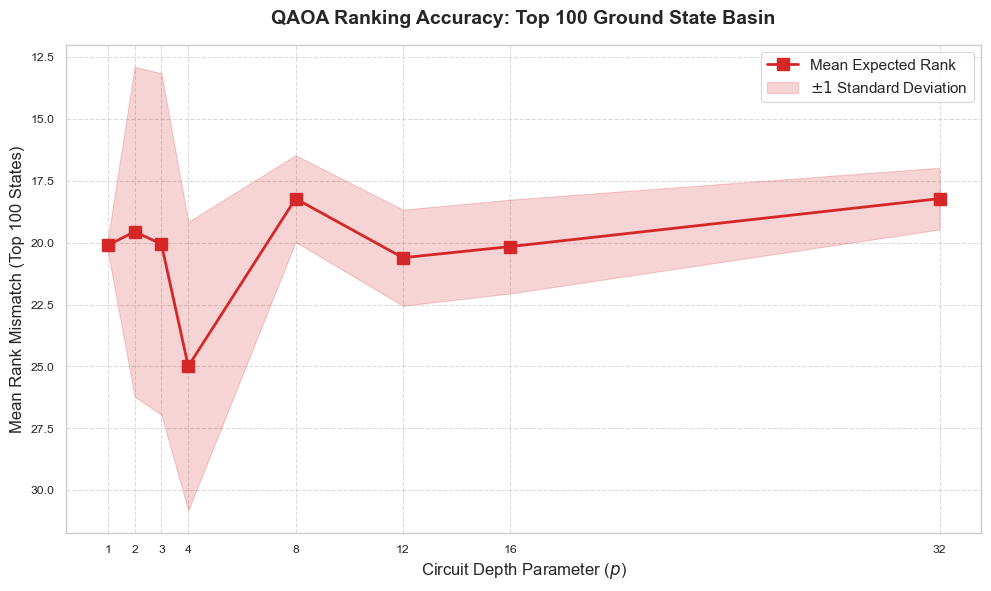

In [33]:
layers = summary_df2['layers'].values
mean_ranks = summary_df2['mean_mismatch'].values
std_ranks = summary_df2['std_mismatch'].values

plt.figure(figsize=(10, 6))

# Plot the Mean Expected Rank
plt.plot(layers, mean_ranks, marker='s', linestyle='-', color='#d62728',
         linewidth=2, markersize=8, label='Mean Expected Rank')

# Fill the Standard Deviation Bounds
plt.fill_between(layers,
                 mean_ranks - std_ranks,
                 mean_ranks + std_ranks,
                 color='#d62728', alpha=0.2,
                 label='$± 1$ Standard Deviation')

# Academic Formatting
plt.title('QAOA Ranking Accuracy: Top 100 Ground State Basin',
          fontsize=14, fontweight='bold', pad=15)

plt.xlabel('Circuit Depth Parameter ($p$)', fontsize=12)
plt.ylabel('Mean Rank Mismatch (Top 100 States)', fontsize=12)

# Invert the Y-axis so "better" (Rank 1) is physically at the top of the graph (Optional but intuitive)
plt.gca().invert_yaxis()

plt.xticks(layers)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('results/qaoa_expected_rank_scaling.png', dpi=300)
plt.show()

In [34]:
def get_final_files_from_dir(results_folder: str) -> list[str]:
    import glob, os

    os.chdir(results_folder)
    final_files = [f"{results_folder}/{file}" for file in glob.glob("*_final.pkl")]
    os.chdir("..")

    return final_files

def get_df_for_files(files: list[str]):
    return {
        file.split("/")[-1][:-4]: pd.read_pickle(file) for file in files
    }

def mean_rank_matches(group):
    return pd.Series({
        'mean': np.mean(group)
    })

In [40]:
dataframes = get_df_for_files(get_final_files_from_dir(results_folder="overnight_results"))
for name, df in dataframes.items():
    df['rank_matches'] = df['rank_matches'].apply(mean_rank_matches)

    _, n, size, _ = name.split("_")
    start, end = size.split("-")

    df['ROTAMER_COUNT'] = int(n)
    df['START'] = int(start)
    df['END'] = int(end)
    df['SIZE_STR'] = size
    df['RESIDUE_LENGTH'] = int(end) - int(start) + 1

large_df = pd.concat([frame for frame in dataframes.values()])
large_df

,layers,seed,rank_matches,ROTAMER_COUNT,START,END,SIZE_STR,RESIDUE_LENGTH
0,1,0,27.16,5,21,26,21-26,6
1,1,1,27.48,5,21,26,21-26,6
2,1,2,26.94,5,21,26,21-26,6
3,1,3,26.36,5,21,26,21-26,6
4,1,4,26.16,5,21,26,21-26,6
...,...,...,...,...,...,...,...,...
145,12,25,25.90,5,20,25,20-25,6
146,12,26,26.46,5,20,25,20-25,6
147,12,27,26.74,5,20,25,20-25,6
148,12,28,25.66,5,20,25,20-25,6


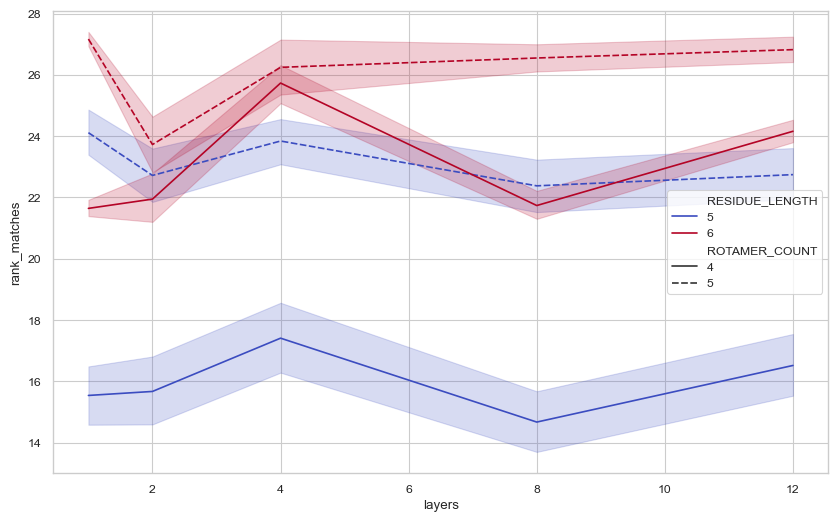

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=large_df,
             x="layers", y="rank_matches",
             hue='RESIDUE_LENGTH', style='ROTAMER_COUNT',
             markers=False, legend='brief',
             palette=sns.color_palette('coolwarm', as_cmap = True),
             ax=ax)
plt.show()

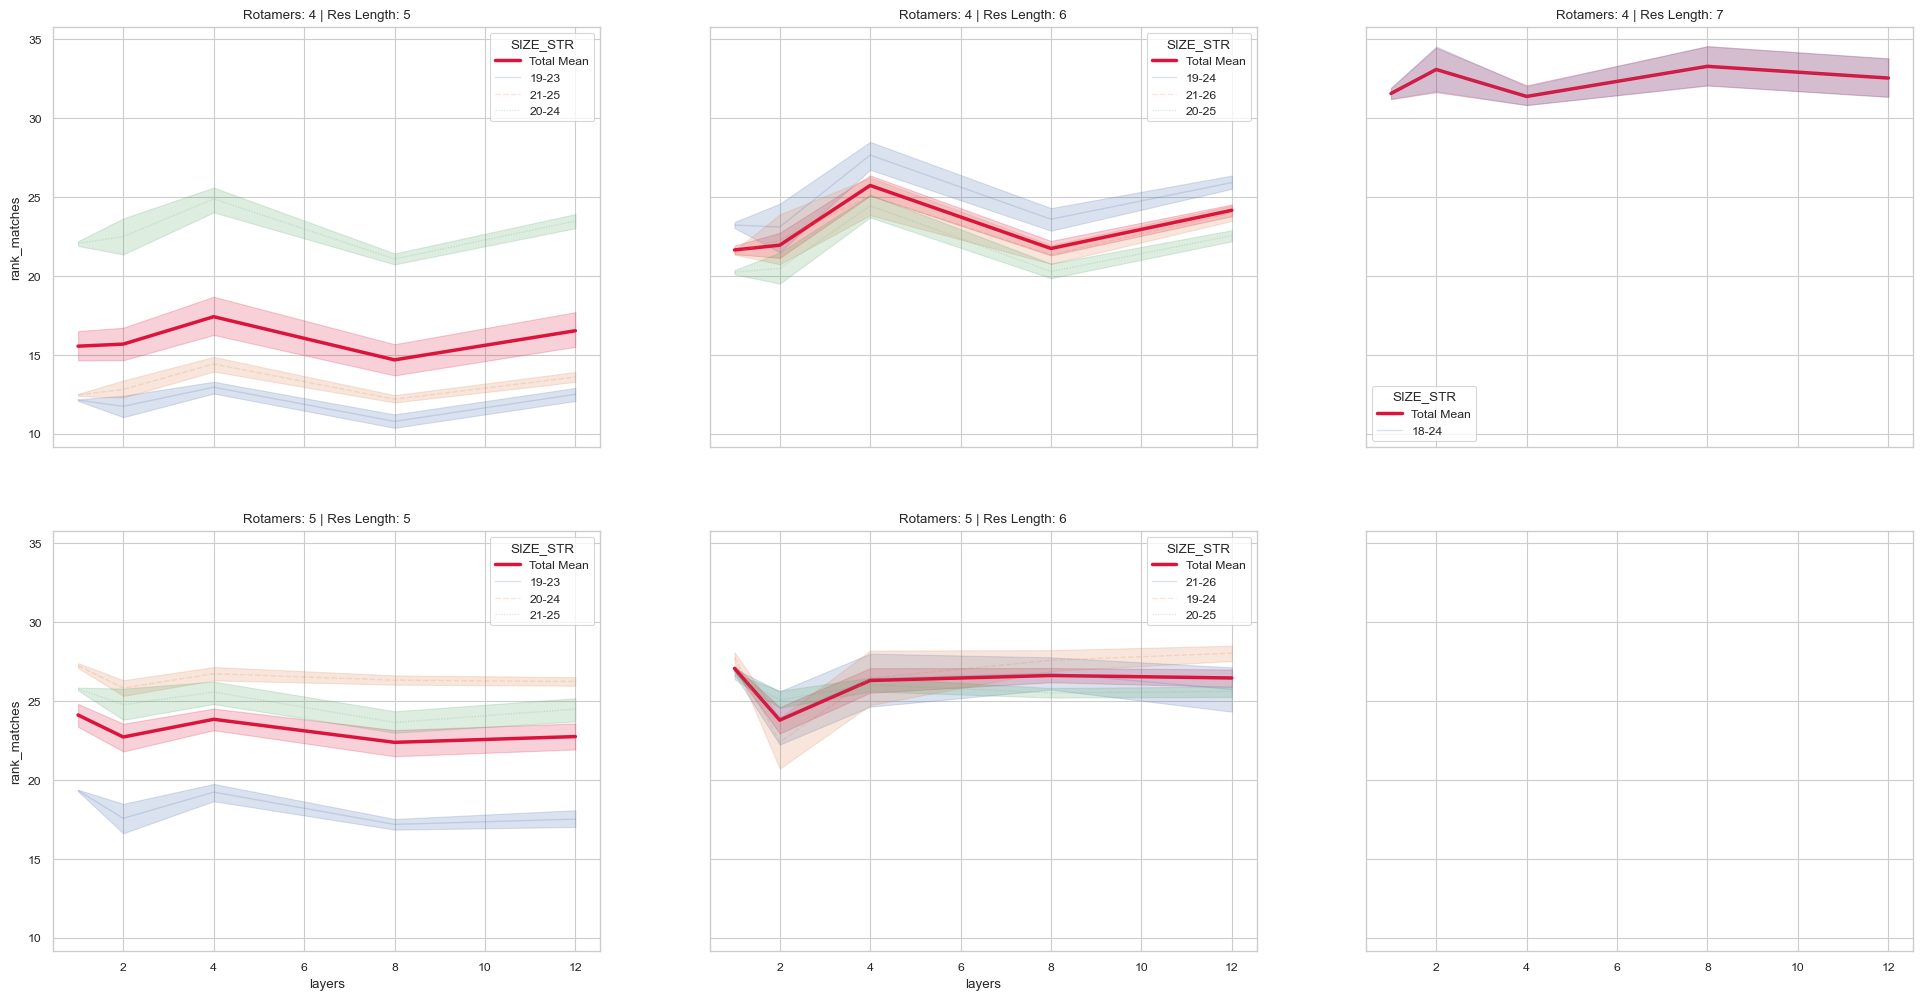

In [41]:
unique_rot_counts, unique_res_lengths = large_df.nunique()['ROTAMER_COUNT'], large_df.nunique()['RESIDUE_LENGTH']
fig, axes = plt.subplots(unique_rot_counts, unique_res_lengths, figsize=(8*unique_res_lengths, 6*unique_rot_counts), sharex=True, sharey=True)

for (label, df), ax in zip(large_df.groupby(['ROTAMER_COUNT', 'RESIDUE_LENGTH']), axes.flat):
    sns.lineplot(
        data=df,
        x="layers", y="rank_matches",
        # hue='SIZE_STR', style='SIZE_STR',
        color='crimson',
        linewidth=2.5,
        label='Total Mean',
        ax=ax
    )
    sns.lineplot(
        data=df,
        x="layers", y="rank_matches",
        hue='SIZE_STR', style='SIZE_STR',
        alpha=0.2,
        linewidth=1,
        ax=ax
    )

    ax.set_title(f"Rotamers: {label[0]} | Res Length: {label[1]}")

plt.savefig("plots/figure-rot-res.svg", dpi=300, bbox_inches='tight')

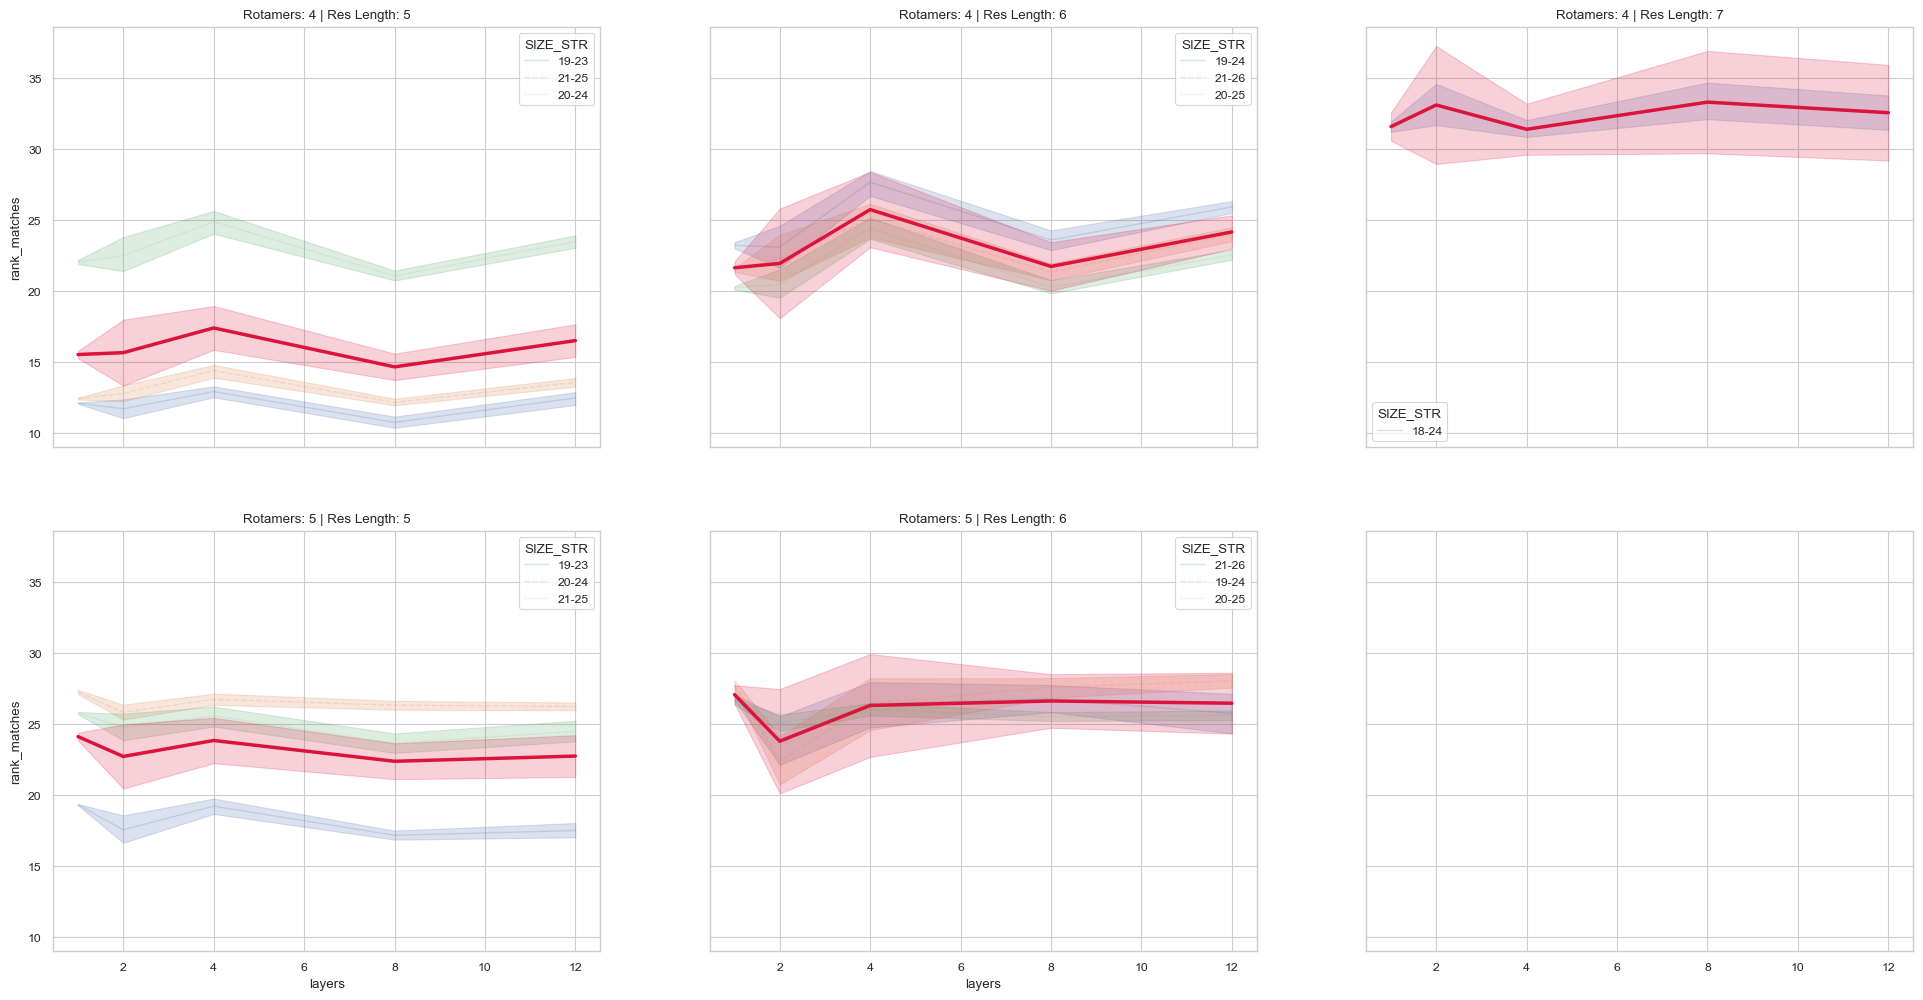

In [43]:
unique_rot_counts, unique_res_lengths = large_df.nunique()['ROTAMER_COUNT'], large_df.nunique()['RESIDUE_LENGTH']
fig, axes = plt.subplots(unique_rot_counts, unique_res_lengths, figsize=(8*unique_res_lengths, 6*unique_rot_counts), sharex=True, sharey=True)

for (label, df), ax in zip(large_df.groupby(['ROTAMER_COUNT', 'RESIDUE_LENGTH']), axes.flat):

    # 1. Plot individual background lines
    sns.lineplot(
        data=df,
        x="layers", y="rank_matches",
        hue='SIZE_STR', style='SIZE_STR',
        alpha=0.2,
        linewidth=1,
        ax=ax
    )

    # 2. Calculate the mean and std for each SIZE_STR at each layer
    group_stats = df.groupby(['layers', 'SIZE_STR'])['rank_matches'].agg(['mean', 'std']).reset_index()

    # 3. Average the means and standard deviations across the SIZE_STR groups
    avg_stats = group_stats.groupby('layers').agg(
        avg_mean=('mean', 'mean'),
        avg_std=('std', 'mean')
    ).reset_index()

    # 4. Plot the new "Total Mean" line using the averaged data
    ax.plot(
        avg_stats['layers'],
        avg_stats['avg_mean'],
        color='crimson',
        linewidth=2.5,
        label='Total Mean'
    )

    # 5. Plot the averaged error band
    ax.fill_between(
        avg_stats['layers'],
        avg_stats['avg_mean'] - avg_stats['avg_std'],
        avg_stats['avg_mean'] + avg_stats['avg_std'],
        color='crimson',
        alpha=0.2
    )

    ax.set_title(f"Rotamers: {label[0]} | Res Length: {label[1]}")

plt.savefig("plots/figure-rot-res2.svg", dpi=300, bbox_inches='tight')